## EDA

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df = pd.read_csv("Pharma_Industry.csv")

In [40]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [41]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None
       Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
count        500.000000                      500.000000        500.000000   
mean          -0.037761                        0.214957          0.062871   
std            0.979891                        1.247567          0.971978   
min           -3.019512                     

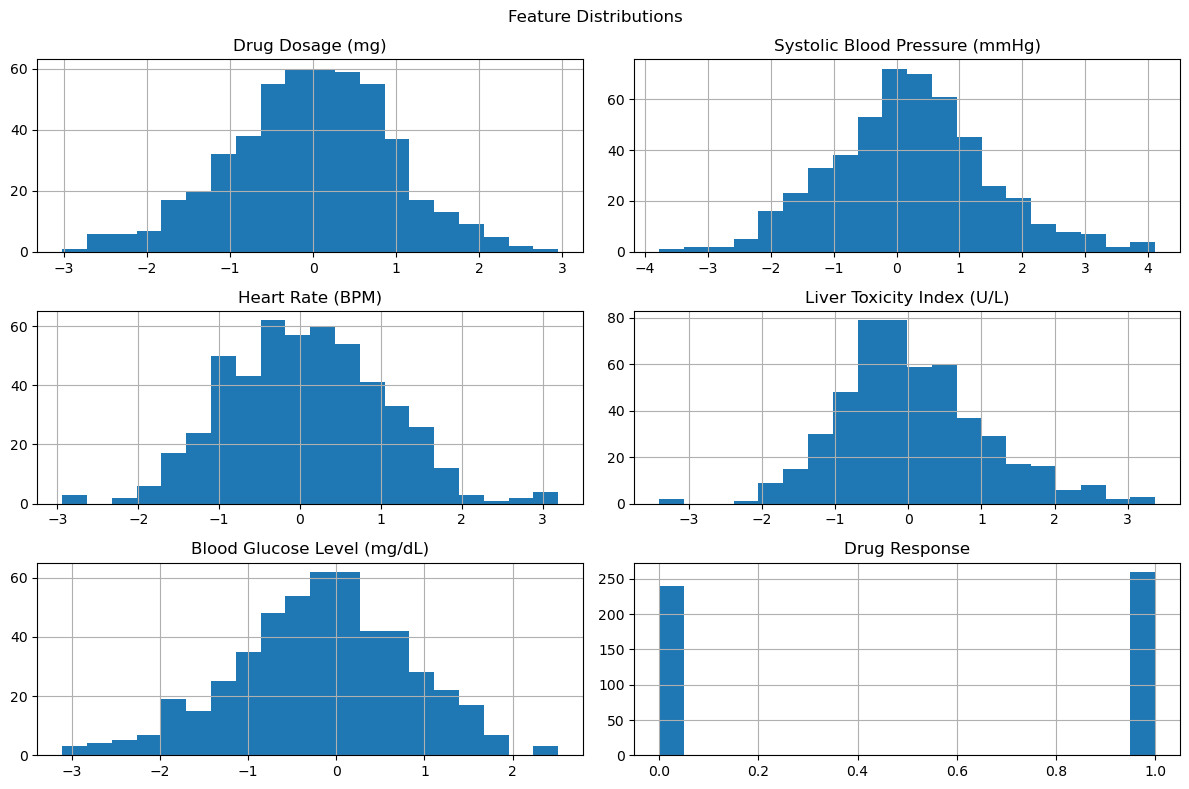

In [32]:
df.hist(figsize=(12,8), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

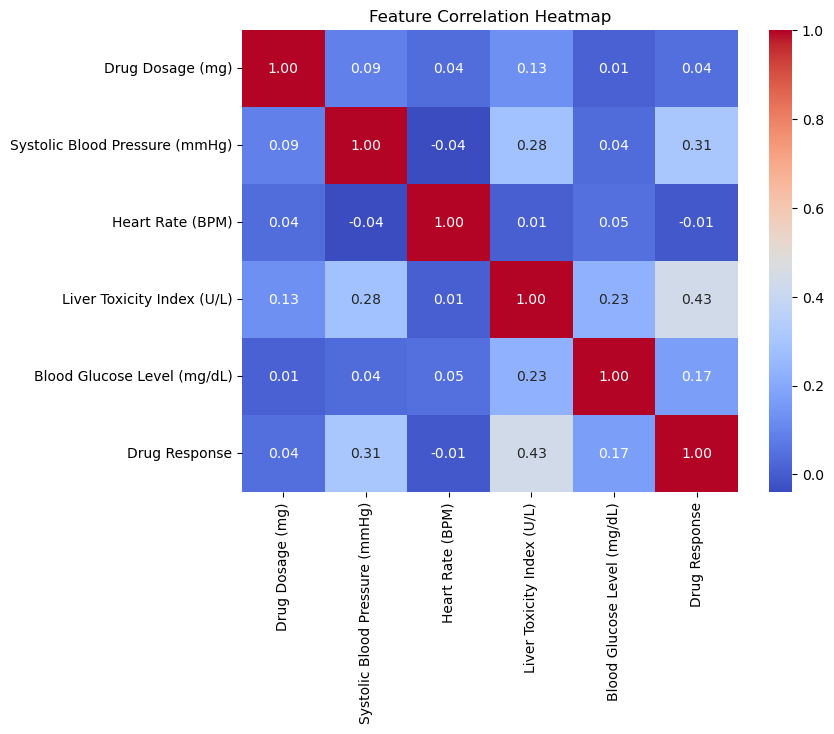

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

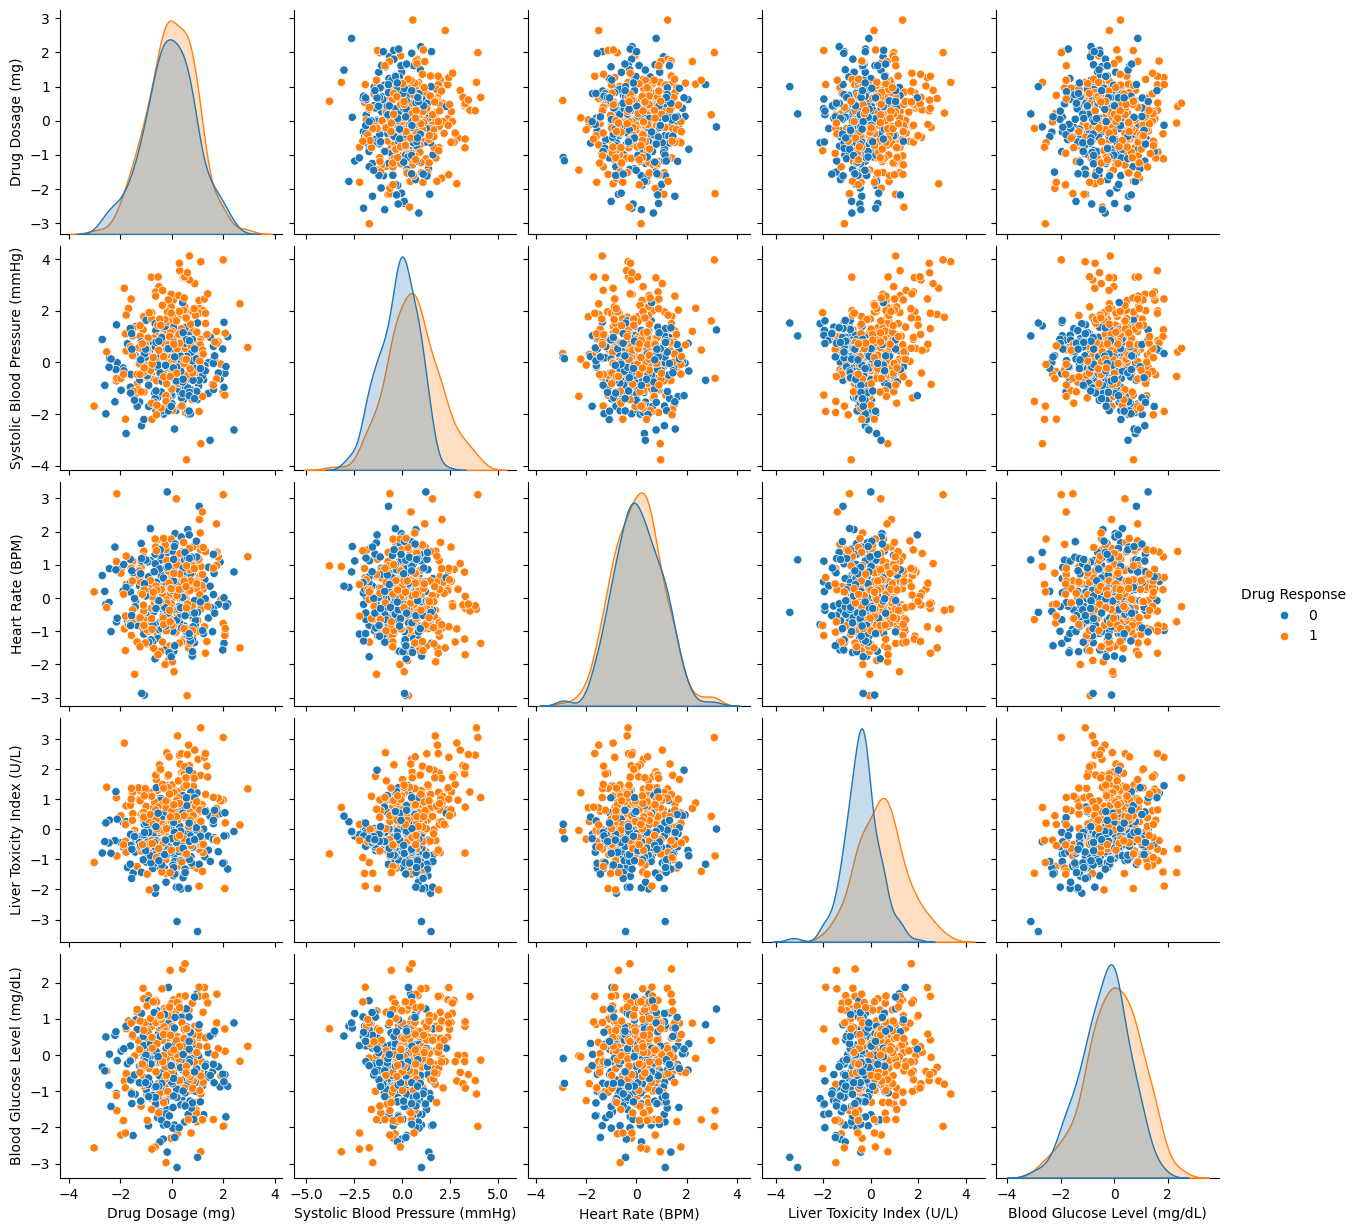

In [34]:
sns.pairplot(df, hue="Drug Response", diag_kind="kde")
plt.show()

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

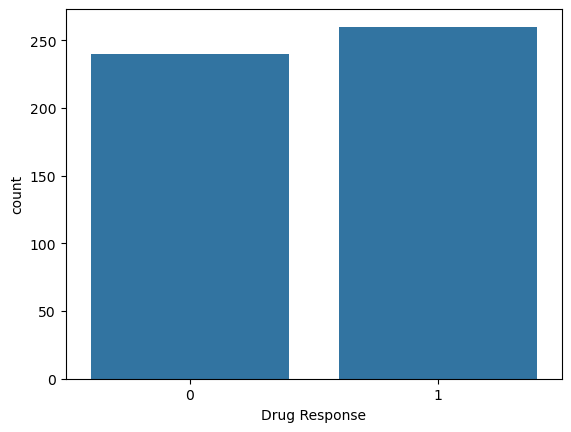

In [7]:
sns.countplot(x='Drug Response', data=df)
plt.show()

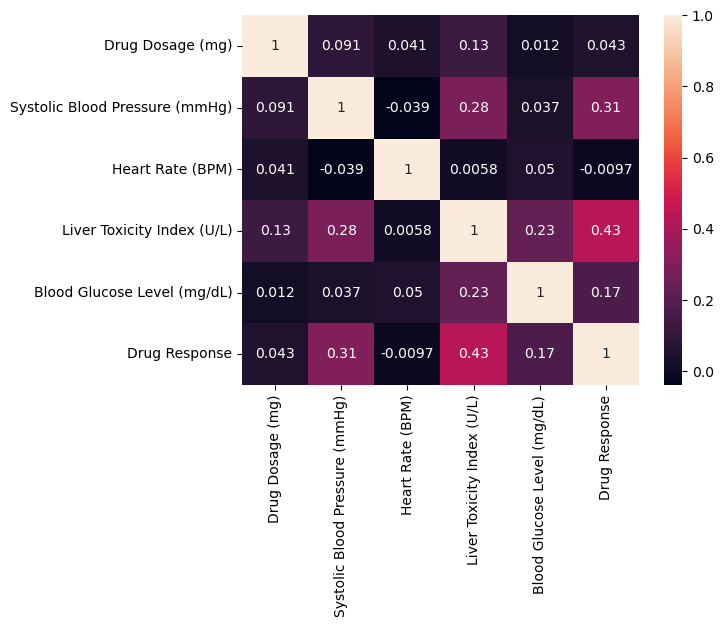

In [8]:
sns.heatmap(df.corr(), annot=True)
plt.show()

## Data Preprocessing

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [11]:
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print("Training Score:", train_score)
print("Test Score:", test_score)

Training Score: 0.7125
Test Score: 0.79


# Visualization

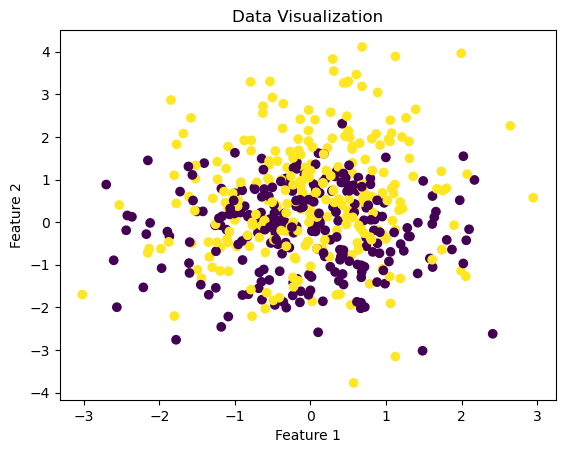

In [18]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df['Drug Response'])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Data Visualization")
plt.show()

 # SVM Implementation

In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [20]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [21]:
y_pred = model.predict(X_test)

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



In [23]:
train_score = model.score(X_train, y_train)
print("Train Accuracy:", train_score)

Train Accuracy: 0.71


# Visualization of Results

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


In [25]:
cm = confusion_matrix(y_test, y_pred)

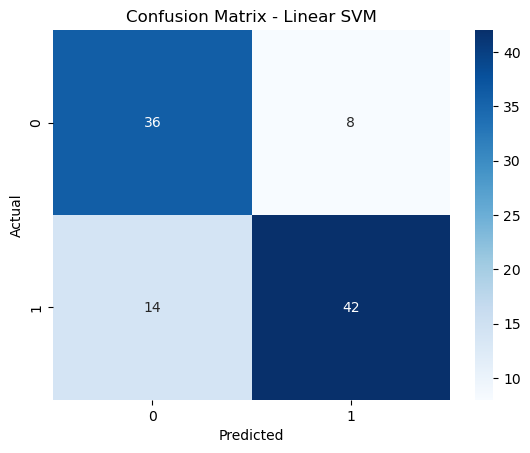

In [44]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Linear SVM")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Parameter Tuning

In [45]:
for c in [0.1, 1, 10, 100]:
    m = SVC(kernel="rbf", C=c)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"C={c} → Accuracy: {acc:.2f}")

C=0.1 → Accuracy: 0.80
C=1 → Accuracy: 0.84
C=10 → Accuracy: 0.78
C=100 → Accuracy: 0.70


# Comparison

In [46]:
model_rbf = SVC(kernel="rbf")
model_rbf.fit(X_train, y_train)


SVC()

In [47]:
pred_rbf = model_rbf.predict(X_test)
print("RBF Accuracy:", accuracy_score(y_test, pred_rbf))

RBF Accuracy: 0.84


In [48]:
model_poly = SVC(kernel="poly")
model_poly.fit(X_train, y_train)


SVC(kernel='poly')

In [49]:
pred_poly = model_poly.predict(X_test)

In [50]:
print("Linear:", accuracy_score(y_test, y_pred))
print("RBF:", accuracy_score(y_test, pred_rbf))
print("Poly:", accuracy_score(y_test, pred_poly))

Linear: 0.78
RBF: 0.84
Poly: 0.71


In [51]:
print("RBF Report:")
print(classification_report(y_test, pred_rbf))
print("Poly Report:")
print(classification_report(y_test, pred_poly))

RBF Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        44
           1       0.87      0.84      0.85        56

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100

Poly Report:
              precision    recall  f1-score   support

           0       0.62      0.91      0.73        44
           1       0.89      0.55      0.68        56

    accuracy                           0.71       100
   macro avg       0.75      0.73      0.71       100
weighted avg       0.77      0.71      0.70       100



## Analysis & Observations

- RBF kernel performed best (84%) — confirms data is non-linearly separable
- Linear kernel underfit (train=71%, test=78%) — data too complex for a straight boundary
- Poly kernel overfit in opposite direction (71% test) — too complex for this dataset
- Higher C values reduce regularization — model fits training data more tightly

## Real-World Implications

- In pharma, false negatives (predicting no response when drug works) are costly
- SVM with RBF is suitable here but needs more data for production use
- Feature engineering (e.g., drug-dosage interaction terms) could further improve accuracy